<a href="https://colab.research.google.com/github/pathakarunima25-cell/Capstone_ASL_classification/blob/main/Capstone_4(baseline)_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

base_path = "/content/drive/MyDrive/Capstone Project 2026/Sign-Language-Digits-Dataset-master/Sign-Language-Digits-Dataset-master/Dataset/split_dataset"

import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Separate datagens - augmentation ONLY for training
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False
)

datagen_val = ImageDataGenerator(rescale=1./255)  # NO augmentation

train_generator = datagen_train.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True)

val_generator = datagen_val.flow_from_directory(
    os.path.join(base_path, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

test_generator = datagen_val.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

Found 1438 images belonging to 10 classes.
Found 304 images belonging to 10 classes.
Found 320 images belonging to 10 classes.


In [3]:
# Build brand new model - never reuse a previously trained one
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),        # slightly increased from 0.2
    layers.Dense(10, activation='softmax')
])

model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model_tl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_tl = model_tl.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.3767 - loss: 1.8590 - val_accuracy: 0.7401 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 402ms/step - accuracy: 0.7204 - loss: 0.8299 - val_accuracy: 0.8454 - val_loss: 0.4899 - learning_rate: 0.0010
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 401ms/step - accuracy: 0.8135 - loss: 0.5575 - val_accuracy: 0.8388 - val_loss: 0.4531 - learning_rate: 0.0010
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 399ms/step - accuracy: 0.8557 - loss: 0.4430 - val_accuracy: 0.8586 - val_loss: 0.3769 - learning_rate: 0.0010
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 403ms/step - accuracy: 0.8738 - loss: 0.3681 - val_accuracy: 0.8454 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 398ms/step - accuracy: 0.8823 - loss: 0.3551 - val_accuracy: 0.8355 - val_loss: 0.3983 - learning_rate: 0.0010
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 402ms/step - accuracy: 0.9080 - loss: 0.288

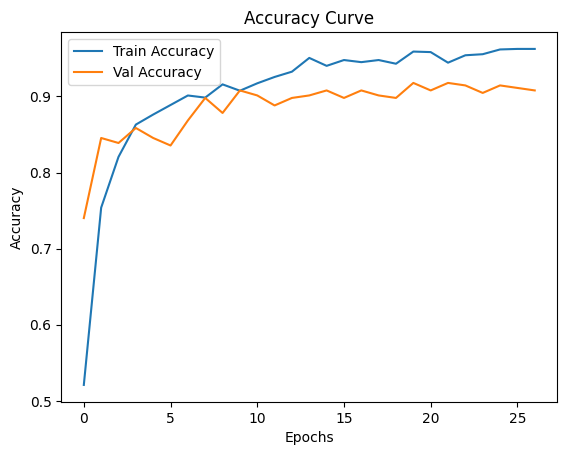

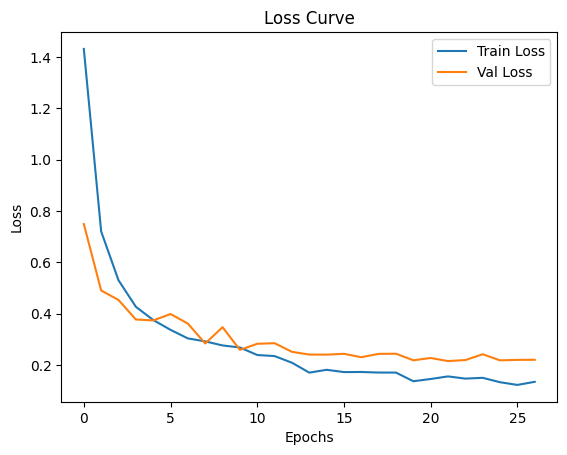

In [5]:
# Plot Training & Validation Accuracy
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Training & Validation Loss
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict test data
y_pred = model_tl.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Class labels (folder names)
class_labels = list(test_generator.class_indices.keys())

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        32
           2       0.90      0.88      0.89        32
           3       0.94      0.94      0.94        32
           4       0.93      0.78      0.85        32
           5       0.94      1.00      0.97        32
           6       0.82      0.88      0.85        32
           7       0.89      0.78      0.83        32
           8       0.72      0.91      0.81        32
           9       0.93      0.88      0.90        32

    accuracy                           0.90       320
   macro avg       0.91      0.90      0.90       320
weighted avg       0.91      0.90      0.90       320



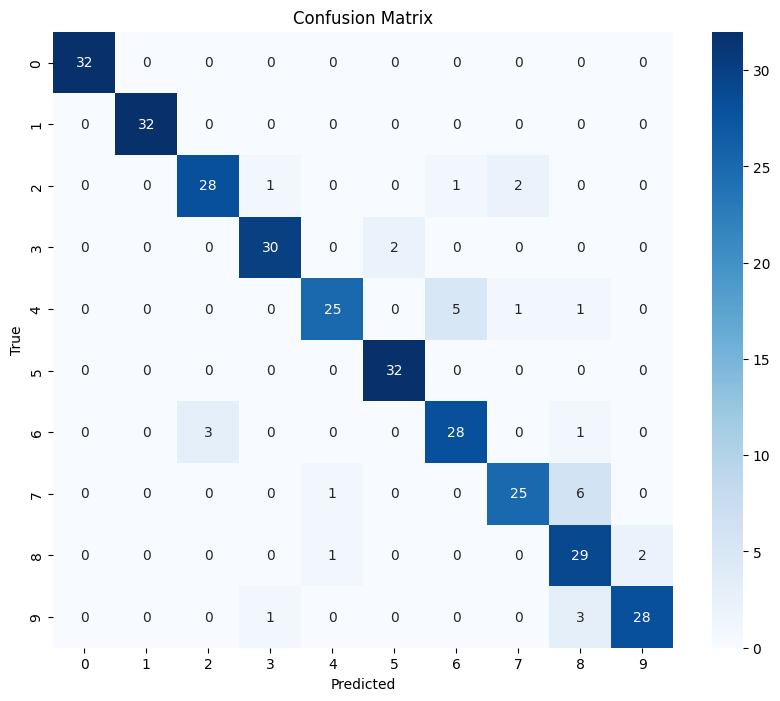

In [11]:
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

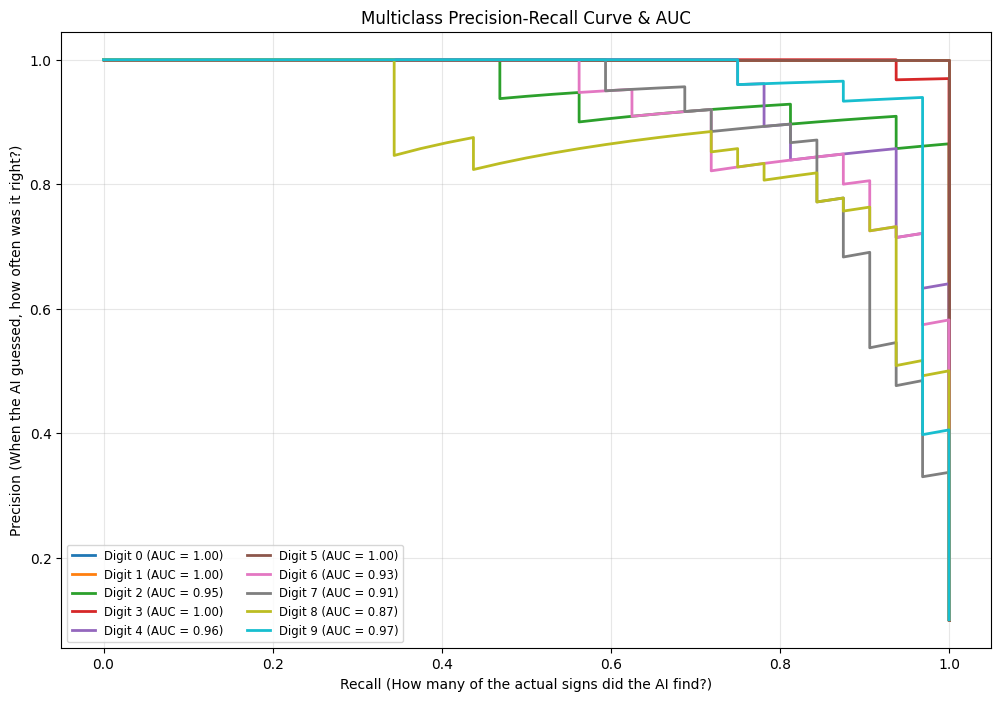

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Binarize the true labels (Convert 0-9 digits into a binary format for the plot)
# This is necessary because the PR Curve is technically a binary calculation
# that we repeat for all 10 classes.
y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))
n_classes = y_true_bin.shape[1]

# 2. Setup the Plot
plt.figure(figsize=(12, 8))

# 3. Calculate and Plot the curve for each digit (0-9)
for i in range(n_classes):
    # Use the probabilities from y_pred, not the class guesses
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, lw=2, label=f'Digit {class_labels[i]} (AUC = {pr_auc:.2f})')

# 4. Final Formatting
plt.xlabel('Recall (How many of the actual signs did the AI find?)')
plt.ylabel('Precision (When the AI guessed, how often was it right?)')
plt.title('Multiclass Precision-Recall Curve & AUC')
plt.legend(loc="lower left", ncol=2, fontsize='small')
plt.grid(alpha=0.3)
plt.show()

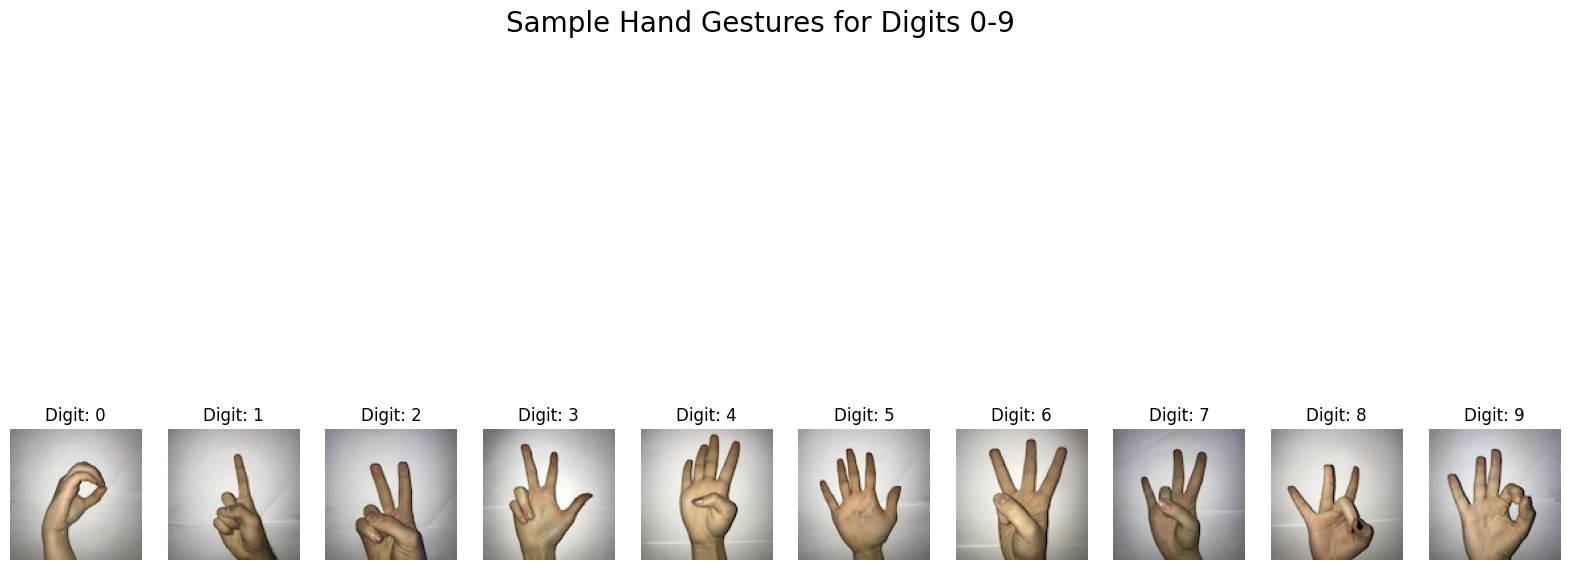

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

# 1. Path to your training data
train_path = os.path.join(base_path, 'train')

# 2. Setup the figure
plt.figure(figsize=(20, 10))

# 3. Loop through each digit folder (0-9)
for i in range(10):
    folder = os.path.join(train_path, str(i))

    # Pick a random image from the folder
    random_image = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, random_image)

    # Load and plot
    img = mpimg.imread(img_path)
    plt.subplot(1, 10, i + 1)
    plt.imshow(img)
    plt.title(f"Digit: {i}")
    plt.axis('off')

plt.suptitle("Sample Hand Gestures for Digits 0-9", fontsize=20)
plt.show()